In [12]:
import pandas as pd 
import numpy as np 
from sklearn.datasets import fetch_openml

# Load complete MNIST dataset
mnist = fetch_openml('mnist_784', version=1, as_frame=True)

# Convert to DataFrame
df = mnist.frame




In [13]:
# Display first 5 rows
df.head()

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784,class
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9


In [14]:
df.shape

(70000, 785)

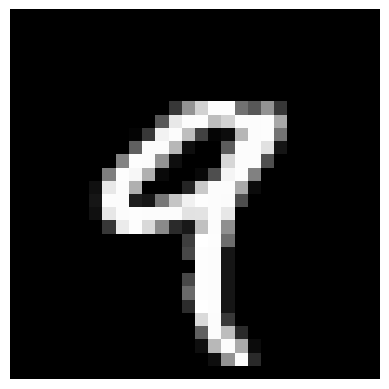

In [15]:
import matplotlib.pyplot as plt
plt.imshow(df.drop('class', axis=1).iloc[4].values.reshape(28, 28), cmap='gray')
plt.axis('off')
plt.show()

In [16]:
x = df.drop('class', axis=1)
y = df['class']

In [17]:
from sklearn.model_selection import train_test_split 

x_train , x_test , y_train , y_test =  train_test_split (x,y , test_size = 0.2 , random_state = 42)
x_train

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
47339,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
67456,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12308,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
32557,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
664,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37194,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6265,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
54886,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
860,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [18]:
from sklearn.preprocessing import StandardScaler

scale = StandardScaler()

x_train = scale.fit_transform(x_train)
x_test = scale.transform(x_test)
x_train.shape

(56000, 784)

In [19]:
# USE PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=100)

x_train_trf = pca.fit_transform(x_train)
x_test_trf = pca.transform(x_test)

print(x_train_trf.shape)
print(x_test_trf.shape)

(56000, 100)
(14000, 100)


In [20]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

model = KNeighborsClassifier()

model.fit(x_train_trf, y_train)

y_pred = model.predict(x_test_trf)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy of the model:", accuracy)

Accuracy of the model: 0.9587857142857142


In [21]:
# Trasformation to a 2D coordination system 

pca = PCA(n_components=2) 
x_trian_trf = pca.fit_transform(x_train)
x_test_trf = pca.transform(x_test)

x_trian_trf

array([[ -0.66184663,  -3.52844877],
       [ -2.4256249 ,  -3.51506096],
       [ -3.5671334 ,   4.78236184],
       ...,
       [ -8.34347904,  -1.19630488],
       [ 10.4937875 ,  -9.03606709],
       [ 10.57302752, -12.31764924]])

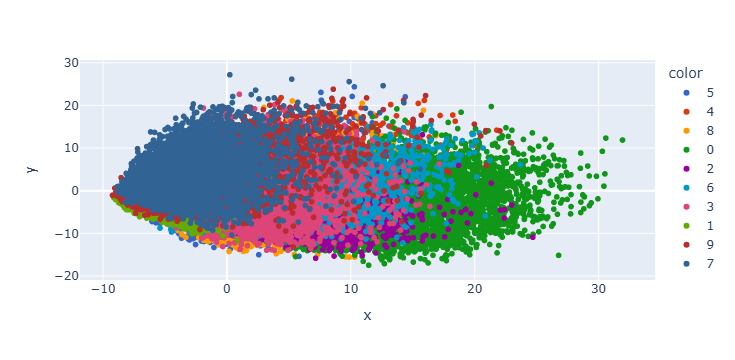

In [23]:
import plotly.express as px

y_train_trf = y_train.astype(str)

fig = px.scatter(
    x=x_train_trf[:, 0],
    y=x_train_trf[:, 1],
    color=y_train_trf,
    color_discrete_sequence=px.colors.qualitative.G10
)

fig.show()

In [24]:
#Transform in 3D 
pca = PCA(n_components=3)
x_train_trf = pca.fit_transform(x_train)
x_test_trf = pca.transform(x_test)

x_trian_trf

array([[ -0.66184663,  -3.52844877],
       [ -2.4256249 ,  -3.51506096],
       [ -3.5671334 ,   4.78236184],
       ...,
       [ -8.34347904,  -1.19630488],
       [ 10.4937875 ,  -9.03606709],
       [ 10.57302752, -12.31764924]])

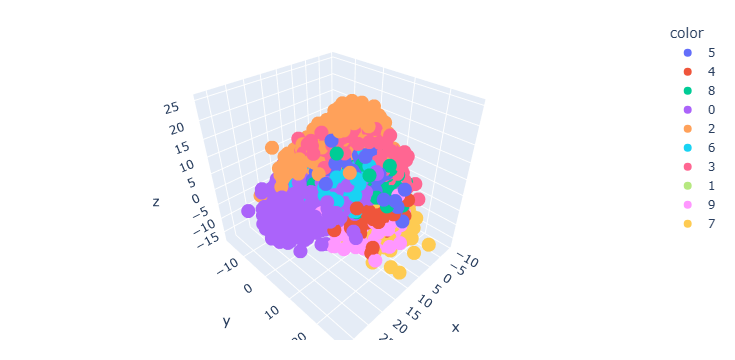

In [27]:
import plotly.express as px

y_train_trf = y_train.astype(str)

fig = px.scatter_3d(
    x=x_train_trf[:, 0],
    y=x_train_trf[:, 1],
    z=x_train_trf[:, 2],
    color=y_train_trf
)

fig.update_layout(
    margin=dict(l=20, t=20, b=20)
)

fig.show()